In [1]:
# ============================================================
# CS5812 - Predictive Data Analysis
# FIXED: Country-Normalised Weighted Z-Score Y Construction
# Removes England population bias by z-scoring within country
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:
FILE_PATH = '/content/drive/MyDrive/Sample_data/PDA_DATA.csv'
df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip()

COL_FIRE      = 'daily_count'
COL_ACCIDENTS = 'Amount of collisions happen each day'
COL_COUNTRY   = 'country'          # ← adjust if your column is named differently

print("=" * 60)
print("  DATA LOADED")
print("=" * 60)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

# ── VERIFY COUNTRY COLUMN EXISTS ────────────────────────────
if COL_COUNTRY not in df.columns:
    raise KeyError(
        f"\n❌  Country column '{COL_COUNTRY}' not found."
        f"\n    Available columns: {list(df.columns)}"
    )

countries = df[COL_COUNTRY].unique()
print(f"\n  Countries found: {list(countries)}")

  DATA LOADED
  Rows    : 12,054
  Columns : 17

  Countries found: ['England', 'Scotland', 'Wales']


In [8]:
# ============================================================
# SECTION A — DEMONSTRATE THE BIAS PROBLEM
# ============================================================

print("\n" + "=" * 60)
print("  BIAS DEMONSTRATION — Raw incident counts by country")
print("=" * 60)

bias_summary = df.groupby(COL_COUNTRY)[[COL_FIRE, COL_ACCIDENTS]].agg(['mean','median'])
print(bias_summary.round(2))

print("""
  ── WHY THIS IS A PROBLEM ────────────────────────────────────
  England's mean daily incidents are far higher than Wales,
  Scotland or Northern Ireland — not because England is more
  dangerous proportionally, but because it has ~18x the
  population of Wales.

  If we z-score globally:
    → England median rows score ABOVE the global median
    → Nearly every England day = "High Risk"
    → Nearly every N.Ireland day = "Low Risk"
    → The model learns country identity, not real risk factors

  Fix: z-score WITHIN each country separately.
  "High risk" then means: unusually high for THAT country's
  own baseline — a fair, population-neutral definition.
  ─────────────────────────────────────────────────────────────
""")



  BIAS DEMONSTRATION — Raw incident counts by country
         daily_count          Amount of collisions happen each day       
                mean   median                                 mean median
country                                                                  
England      1522.78  1466.50                               235.17  238.0
Scotland       77.37    66.00                                15.56   15.0
Wales          71.85    60.71                                10.25   10.0

  ── WHY THIS IS A PROBLEM ────────────────────────────────────
  England's mean daily incidents are far higher than Wales,
  Scotland or Northern Ireland — not because England is more
  dangerous proportionally, but because it has ~18x the
  population of Wales.
 
  If we z-score globally:
    → England median rows score ABOVE the global median
    → Nearly every England day = "High Risk"
    → Nearly every N.Ireland day = "Low Risk"
    → The model learns country identity, not real risk factor

Now lets do the PCA within each country

In [9]:
# ============================================================
# SECTION B — PCA WITHIN EACH COUNTRY
# ============================================================

print("=" * 60)
print("  PCA RESULTS — Per Country")
print("=" * 60)

pca_weights_per_country = {}

for country in sorted(countries):
    subset = df[df[COL_COUNTRY] == country][[COL_FIRE, COL_ACCIDENTS]].dropna()

    if len(subset) < 10:
        print(f"\n  ⚠️  {country}: too few rows ({len(subset)}), skipping PCA")
        # Fall back to equal weights for very small subsets
        pca_weights_per_country[country] = (0.5, 0.5)
        continue

    scaler  = StandardScaler()
    scaled  = scaler.fit_transform(subset)

    pca     = PCA(n_components=2)
    pca.fit(scaled)

    loadings       = pca.components_[0]
    explained_var  = pca.explained_variance_ratio_
    abs_loadings   = np.abs(loadings)
    weights        = abs_loadings / abs_loadings.sum()

    pca_weights_per_country[country] = (weights[0], weights[1])

    print(f"\n  {country}:")
    print(f"    PC1 explains         : {explained_var[0]*100:.1f}%")
    print(f"    PC2 explains         : {explained_var[1]*100:.1f}%")
    print(f"    PC1 loading (fires)  : {loadings[0]:+.4f}")
    print(f"    PC1 loading (collis) : {loadings[1]:+.4f}")
    print(f"    → w_fire             : {weights[0]:.4f}")
    print(f"    → w_accidents        : {weights[1]:.4f}")

    if explained_var[0] >= 0.55:
        print(f"    ✅  PC1 > 55% — combining justified")
    else:
        print(f"    ⚠️  PC1 < 55% — variables share less common variance")


  PCA RESULTS — Per Country

  England:
    PC1 explains         : 54.9%
    PC2 explains         : 45.1%
    PC1 loading (fires)  : +0.7071
    PC1 loading (collis) : +0.7071
    → w_fire             : 0.5000
    → w_accidents        : 0.5000
    ⚠️  PC1 < 55% — variables share less common variance

  Scotland:
    PC1 explains         : 53.3%
    PC2 explains         : 46.7%
    PC1 loading (fires)  : +0.7071
    PC1 loading (collis) : +0.7071
    → w_fire             : 0.5000
    → w_accidents        : 0.5000
    ⚠️  PC1 < 55% — variables share less common variance

  Wales:
    PC1 explains         : 58.7%
    PC2 explains         : 41.3%
    PC1 loading (fires)  : +0.7071
    PC1 loading (collis) : +0.7071
    → w_fire             : 0.5000
    → w_accidents        : 0.5000
    ✅  PC1 > 55% — combining justified


Country normalised Z-score and composite Y

In [10]:

# ============================================================
# SECTION C — COUNTRY-NORMALISED Z-SCORES + COMPOSITE Y
# ============================================================

# ── Compute z-scores WITHIN each country ────────────────────
df['fires_z']      = np.nan
df['collisions_z'] = np.nan
df['Y_severity']   = np.nan

for country, (w_fire, w_acc) in pca_weights_per_country.items():
    mask = df[COL_COUNTRY] == country

    # Z-score within this country only
    fire_mean  = df.loc[mask, COL_FIRE].mean()
    fire_std   = df.loc[mask, COL_FIRE].std()
    acc_mean   = df.loc[mask, COL_ACCIDENTS].mean()
    acc_std    = df.loc[mask, COL_ACCIDENTS].std()

    df.loc[mask, 'fires_z'] = (
        (df.loc[mask, COL_FIRE] - fire_mean) / fire_std
    )
    df.loc[mask, 'collisions_z'] = (
        (df.loc[mask, COL_ACCIDENTS] - acc_mean) / acc_std
    )
    df.loc[mask, 'Y_severity'] = (
        w_fire * df.loc[mask, 'fires_z'] +
        w_acc  * df.loc[mask, 'collisions_z']
    )

    print(f"\n  {country}  |  w_fire={w_fire:.3f}  w_acc={w_acc:.3f}")
    print(f"    fires    : mean={fire_mean:.1f}  std={fire_std:.2f}")
    print(f"    accidents: mean={acc_mean:.1f}  std={acc_std:.2f}")


# ── Binary Y: threshold is median WITHIN each country ────────
# This ensures exactly ~50/50 split per country (fair classification)
df['Y_class'] = np.nan

for country in countries:
    mask     = df[COL_COUNTRY] == country
    median_y = df.loc[mask, 'Y_severity'].median()
    df.loc[mask, 'Y_class'] = (
        df.loc[mask, 'Y_severity'] > median_y
    ).astype(int)


# ── Verify balance per country ───────────────────────────────
print("\n" + "=" * 60)
print("  Y_CLASS BALANCE — Per Country (should be ~50/50 now)")
print("=" * 60)

for country in sorted(countries):
    mask   = df[COL_COUNTRY] == country
    counts = df.loc[mask, 'Y_class'].value_counts()
    total  = counts.sum()
    pct    = counts.get(1, 0) / total * 100
    status = "✅" if 45 <= pct <= 55 else "⚠️ "
    print(f"  {country:<20} High-Risk: {pct:.1f}%  {status}")



  England  |  w_fire=0.500  w_acc=0.500
    fires    : mean=1522.8  std=282.87
    accidents: mean=235.2  std=55.67

  Scotland  |  w_fire=0.500  w_acc=0.500
    fires    : mean=77.4  std=44.93
    accidents: mean=15.6  std=6.19

  Wales  |  w_fire=0.500  w_acc=0.500
    fires    : mean=71.8  std=37.85
    accidents: mean=10.3  std=4.35

  Y_CLASS BALANCE — Per Country (should be ~50/50 now)
  England              High-Risk: 50.0%  ✅
  Scotland             High-Risk: 49.9%  ✅
  Wales                High-Risk: 50.0%  ✅


/tmp/ipykernel_11001/2455993734.py:117: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(freq='M'), COL_COUNTRY])['Y_class']
/tmp/ipykernel_11001/2455993734.py:138: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_11001/2455993734.py:138: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


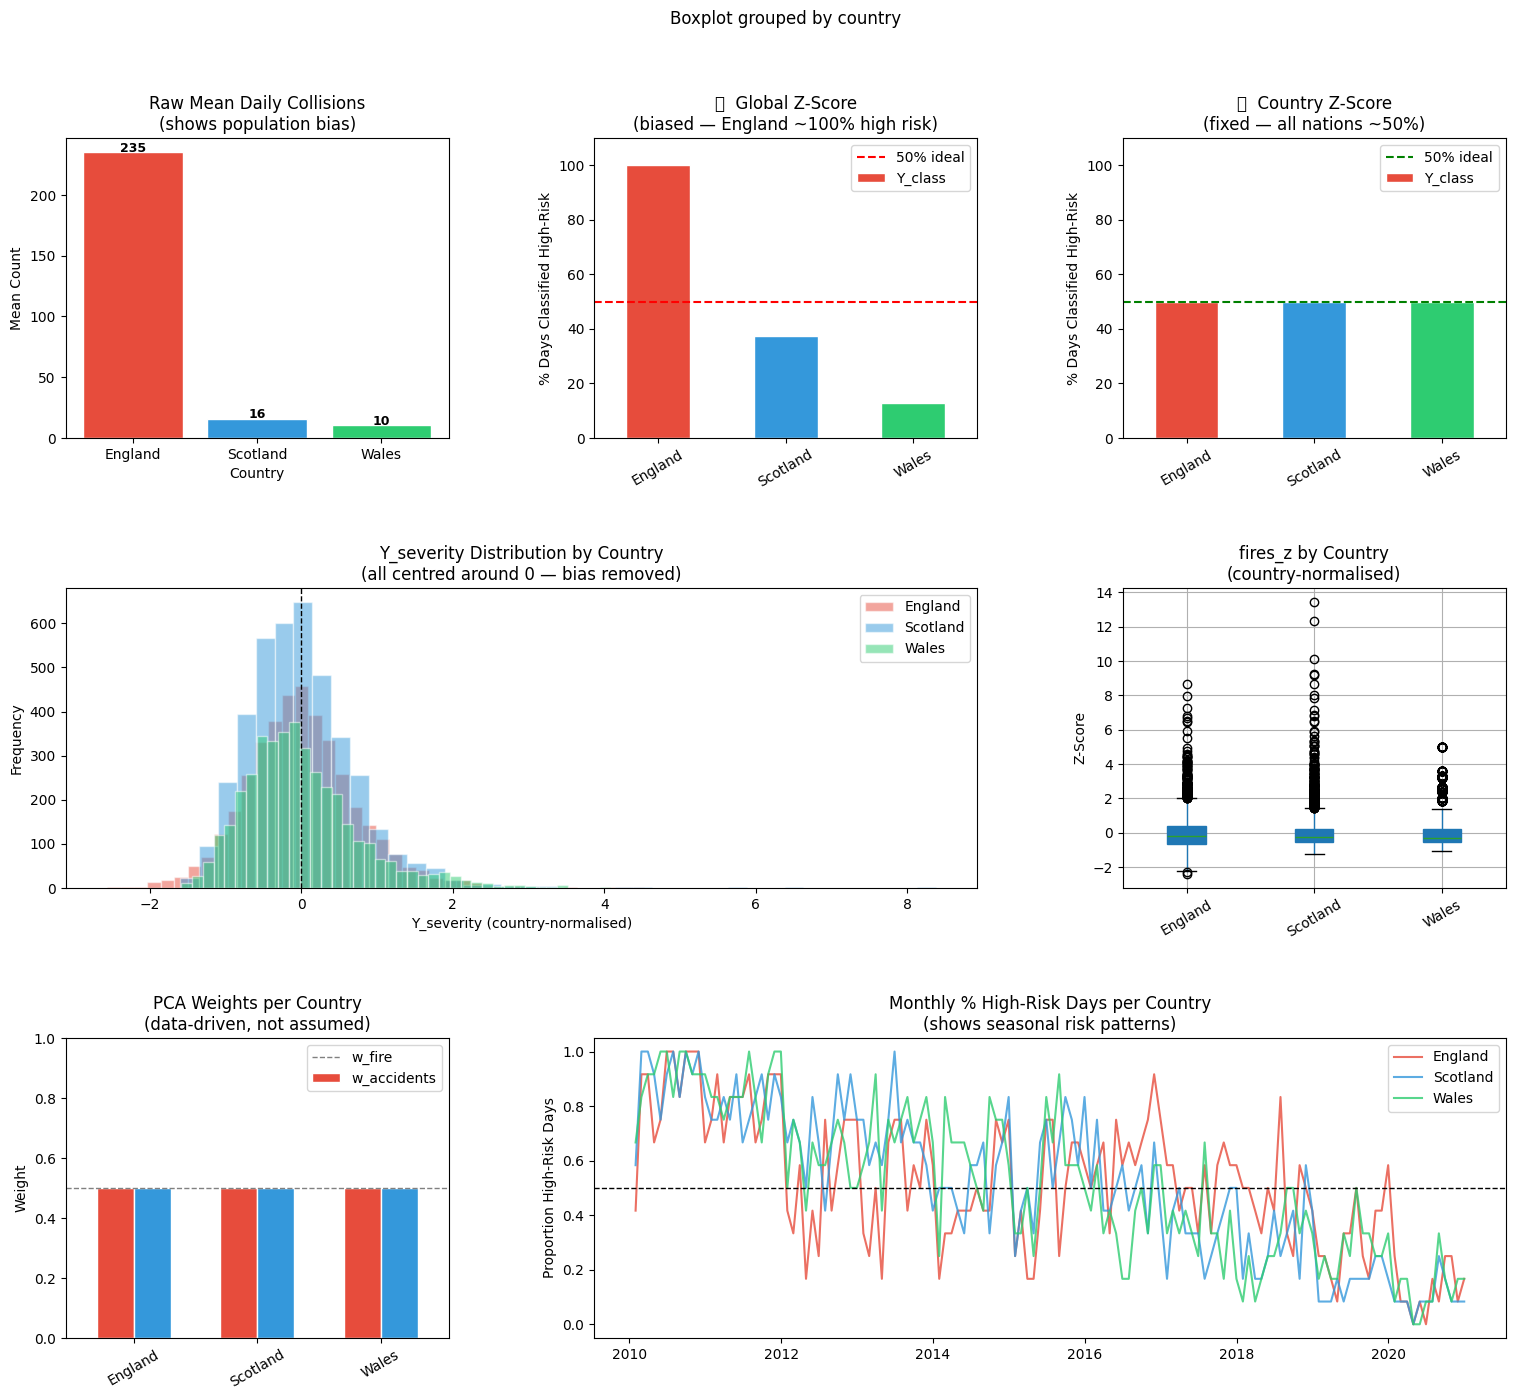


  ✅  Plot saved → Sample_data/PDA_bias_fix.png


In [11]:

fig = plt.figure(figsize=(18, 16))
fig.suptitle(
    'Country-Normalised Y Construction\n'
    'CS5812 — Removing Geographic Population Bias',
    fontsize=14, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

country_colors = {
    c: col for c, col in zip(
        sorted(countries),
        ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    )
}

# ── Plot 1: Raw mean incidents per country (the bias) ────────
ax1 = fig.add_subplot(gs[0, 0])
means = df.groupby(COL_COUNTRY)[COL_ACCIDENTS].mean().sort_values(ascending=False)
bars  = ax1.bar(means.index,
                means.values,
                color=[country_colors.get(c, 'grey') for c in means.index],
                edgecolor='white')
ax1.set_title('Raw Mean Daily Collisions\n(shows population bias)')
ax1.set_ylabel('Mean Count')
ax1.set_xlabel('Country')
for bar, val in zip(bars, means.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')

# ── Plot 2: Global z-score class balance (the broken version)
ax2 = fig.add_subplot(gs[0, 1])
# Recompute global z for demonstration only
global_severity = (
    0.5 * ((df[COL_FIRE]      - df[COL_FIRE].mean())      / df[COL_FIRE].std()) +
    0.5 * ((df[COL_ACCIDENTS] - df[COL_ACCIDENTS].mean()) / df[COL_ACCIDENTS].std())
)
global_class = (global_severity > global_severity.median()).astype(int)
broken_balance = pd.concat(
    [df[COL_COUNTRY], global_class.rename('Y_class')], axis=1
).groupby(COL_COUNTRY)['Y_class'].mean() * 100

broken_balance.plot(kind='bar', ax=ax2,
                    color=[country_colors.get(c,'grey') for c in broken_balance.index],
                    edgecolor='white')
ax2.axhline(50, color='red', linestyle='--', linewidth=1.5, label='50% ideal')
ax2.set_title('❌  Global Z-Score\n(biased — England ~100% high risk)')
ax2.set_ylabel('% Days Classified High-Risk')
ax2.set_xlabel('')
ax2.set_ylim(0, 110)
ax2.legend()
ax2.tick_params(axis='x', rotation=30)

# ── Plot 3: Fixed class balance per country ───────────────────
ax3 = fig.add_subplot(gs[0, 2])
fixed_balance = df.groupby(COL_COUNTRY)['Y_class'].mean() * 100
fixed_balance.plot(kind='bar', ax=ax3,
                   color=[country_colors.get(c,'grey') for c in fixed_balance.index],
                   edgecolor='white')
ax3.axhline(50, color='green', linestyle='--', linewidth=1.5, label='50% ideal')
ax3.set_title('✅  Country Z-Score\n(fixed — all nations ~50%)')
ax3.set_ylabel('% Days Classified High-Risk')
ax3.set_xlabel('')
ax3.set_ylim(0, 110)
ax3.legend()
ax3.tick_params(axis='x', rotation=30)

# ── Plot 4: Y_severity distributions per country ─────────────
ax4 = fig.add_subplot(gs[1, 0:2])
for country in sorted(countries):
    mask = df[COL_COUNTRY] == country
    ax4.hist(df.loc[mask, 'Y_severity'].dropna(),
             bins=40, alpha=0.5,
             color=country_colors.get(country, 'grey'),
             label=country, edgecolor='white')
ax4.axvline(0, color='black', linestyle='--', linewidth=1)
ax4.set_xlabel('Y_severity (country-normalised)')
ax4.set_ylabel('Frequency')
ax4.set_title('Y_severity Distribution by Country\n'
              '(all centred around 0 — bias removed)')
ax4.legend()

# ── Plot 5: Fires z-score comparison ─────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
df.boxplot(column='fires_z', by=COL_COUNTRY, ax=ax5,
           patch_artist=True)
ax5.set_title('fires_z by Country\n(country-normalised)')
ax5.set_xlabel('')
ax5.set_ylabel('Z-Score')
plt.sca(ax5)
plt.xticks(rotation=30)

# ── Plot 6: PCA weights per country ──────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
w_data = pd.DataFrame(pca_weights_per_country,
                       index=['w_fire', 'w_accidents']).T
w_data.plot(kind='bar', ax=ax6, color=['#e74c3c', '#3498db'],
            edgecolor='white', width=0.6)
ax6.axhline(0.5, color='grey', linestyle='--', linewidth=1)
ax6.set_title('PCA Weights per Country\n(data-driven, not assumed)')
ax6.set_ylabel('Weight')
ax6.set_ylim(0, 1)
ax6.legend(['w_fire', 'w_accidents'])
ax6.tick_params(axis='x', rotation=30)

# ── Plot 7: Y_class over time (if date column exists) ─────────
ax7 = fig.add_subplot(gs[2, 1:])
date_col = next(
    (c for c in df.columns
     if 'date' in c.lower() or 'day' in c.lower()),
    None
)
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    monthly = (
        df.set_index(date_col)
          .groupby([pd.Grouper(freq='M'), COL_COUNTRY])['Y_class']
          .mean()
          .unstack()
    )
    for country in monthly.columns:
        ax7.plot(monthly.index, monthly[country],
                 label=country,
                 color=country_colors.get(country, 'grey'),
                 linewidth=1.5, alpha=0.8)
    ax7.axhline(0.5, color='black', linestyle='--', linewidth=1)
    ax7.set_title('Monthly % High-Risk Days per Country\n'
                  '(shows seasonal risk patterns)')
    ax7.set_ylabel('Proportion High-Risk Days')
    ax7.legend(loc='upper right')
else:
    ax7.text(0.5, 0.5,
             'No date column found\n(add date for time series plot)',
             ha='center', va='center', fontsize=12,
             transform=ax7.transAxes)
    ax7.set_title('Time Series (date column not detected)')

plt.savefig(
    '/content/drive/MyDrive/Sample_data/PDA_bias_fix.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\n  ✅  Plot saved → Sample_data/PDA_bias_fix.png")


In [12]:

# ============================================================
# SECTION E — PRINT FINAL FORMULA & SAVE
# ============================================================

print("\n" + "=" * 60)
print("  FINAL FORMULA APPLIED")
print("=" * 60)
print("""
  For each country c separately:

  Step 1 — Country-level z-scores:

    z_fires[c]  = (fires  - μ_fires[c])  / σ_fires[c]
    z_colls[c]  = (colls  - μ_colls[c])  / σ_colls[c]

  Step 2 — PCA-derived weights per country:

    w_fire[c], w_acc[c] = |PC1_loadings[c]| / sum(|PC1_loadings[c]|)

  Step 3 — Composite Y (regression):

    Y_severity[c] = w_fire[c] × z_fires[c] + w_acc[c] × z_colls[c]

  Step 4 — Binary Y (classification):

    Y_class[c] = 1  if Y_severity[c] > median(Y_severity[c])
               = 0  otherwise

  Result: each country has its own baseline.
  "High risk" = unusually risky for THAT nation, not globally.
""")

# Print per-country weights summary
print("  Weights used per country:")
print(f"  {'Country':<22} {'w_fire':>8} {'w_accidents':>12}")
print("  " + "-" * 44)
for country, (wf, wa) in pca_weights_per_country.items():
    print(f"  {country:<22} {wf:>8.4f} {wa:>12.4f}")



  FINAL FORMULA APPLIED

  For each country c separately:
 
  Step 1 — Country-level z-scores:
 
    z_fires[c]  = (fires  - μ_fires[c])  / σ_fires[c]
    z_colls[c]  = (colls  - μ_colls[c])  / σ_colls[c]
 
  Step 2 — PCA-derived weights per country:
 
    w_fire[c], w_acc[c] = |PC1_loadings[c]| / sum(|PC1_loadings[c]|)
 
  Step 3 — Composite Y (regression):
 
    Y_severity[c] = w_fire[c] × z_fires[c] + w_acc[c] × z_colls[c]
 
  Step 4 — Binary Y (classification):
 
    Y_class[c] = 1  if Y_severity[c] > median(Y_severity[c])
               = 0  otherwise
 
  Result: each country has its own baseline.
  "High risk" = unusually risky for THAT nation, not globally.

  Weights used per country:
  Country                  w_fire  w_accidents
  --------------------------------------------
  England                  0.5000       0.5000
  Scotland                 0.5000       0.5000
  Wales                    0.5000       0.5000


Overall percentage of high-risk days across all countries: 50.0%


In [14]:
SAVE_PATH = '/content/drive/MyDrive/Sample_data/PDA_DATA_combinedY.csv'
df.to_csv(SAVE_PATH, index=False)

print(f"\n{'=' * 60}")
print(f"  FILE SAVED → {SAVE_PATH}")
print(f"{'=' * 60}")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"\n  New columns added:")
print(f"    fires_z       — country-normalised z-score of fires")
print(f"    collisions_z  — country-normalised z-score of collisions")
print(f"    Y_severity    — composite regression target (per country)")
print(f"    Y_class       — binary classification target (per country)")
print(f"\n  ✅  Done. Population bias removed.")


  FILE SAVED → /content/drive/MyDrive/Sample_data/PDA_DATA_combinedY.csv
  Rows    : 12,054
  Columns : 21

  New columns added:
    fires_z       — country-normalised z-score of fires
    collisions_z  — country-normalised z-score of collisions
    Y_severity    — composite regression target (per country)
    Y_class       — binary classification target (per country)

  ✅  Done. Population bias removed.
